## **1. OS System Info**

In [ ]:
import os
import platform
import psutil

print("System information")
print("------------------")
print("Operating system:", platform.system(), platform.release())
print("Processor:", platform.processor() or "Google Colab virtual CPU")
print("CPU cores:", os.cpu_count())

memory = psutil.virtual_memory()
print("Total memory:", round(memory.total / (1024**3), 2), "GB")
print("Available memory:", round(memory.available / (1024**3), 2), "GB")

System information
------------------
Operating system: Linux 6.6.122+
Processor: x86_64
CPU cores: 2
Total memory: 12.67 GB
Available memory: 11.13 GB


## **2. Library Info**

In [ ]:
import os
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import xgboost

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.20
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('XGBoost:', xgboost.__version__)
print('Output folder:', OUTPUT_DIR.resolve())

Python: 3.12.13
pandas: 2.2.2
NumPy: 2.0.2
scikit-learn: 1.6.1
XGBoost: 3.3.0
Output folder: /content/outputs


## **3. Initial System info**

In [ ]:
import psutil
import platform
import subprocess

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / 1e9:.2f} GB")
print(f"Available RAM: {ram.available / 1e9:.2f} GB")
print(f"Used RAM: {ram.used / 1e9:.2f} GB ({ram.percent}%)")
print(f"\nCPU cores: {psutil.cpu_count(logical=True)}")
print(f"Processor: {platform.processor()}")
print("\nGPU Info:")
try:
    gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total,memory.used,memory.free', '--format=csv'])
    print(gpu_info.decode('utf-8'))
except Exception:
    print("No GPU detected — you're likely on a CPU-only Colab runtime.")

Total RAM: 13.61 GB
Available RAM: 11.87 GB
Used RAM: 1.40 GB (12.8%)

CPU cores: 2
Processor: x86_64

GPU Info:
No GPU detected — you're likely on a CPU-only Colab runtime.


## **4. Install mlxtend**

In [ ]:
!pip install mlxtend

## **5. Upload CIC-Evasive-PDFMal2022.csv**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CIC-Evasive-PDFMal2022.csv to CIC-Evasive-PDFMal2022.csv


## **6. Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np

#1. Load
df = pd.read_csv('CIC-Evasive-PDFMal2022.csv')   # adjust path if needed

#2. Drop identifier column
df = df.drop(columns=['FileName'])

#3. Fix columns that are numeric but had a few corrupted string entries
cols_to_fix = ['Images', 'Obj', 'Endobj', 'Endstream', 'Xref', 'StartXref', 'PageNo',
               'JS', 'Javascript', 'AA', 'OpenAction', 'Acroform', 'JBIG2Decode',
               'RichMedia', 'Launch', 'EmbeddedFile', 'XFA']
for c in cols_to_fix:
    df[c] = pd.to_numeric(df[c], errors='coerce')   # junk strings -> NaN

#4. Encode 'Text' explicitly (Yes/No/unclear/-1/0)
df['Text'] = df['Text'].map({'Yes': 1, 'No': 0, 'unclear': -1, '-1': -1, '0': 0})

#5. Extract PDF version number from 'Header'
df['header_version'] = df['Header'].str.extract(r'PDF-(\d\.\d)').astype(float)
df = df.drop(columns=['Header'])

#6. Encode target (drop any row where Class isn't clearly labeled)
df['Class'] = df['Class'].map({'Benign': 0, 'Malicious': 1})
df = df.dropna(subset=['Class'])

#7. Treat -1 sentinels as missing values
feature_cols = [c for c in df.columns if c != 'Class']
df[feature_cols] = df[feature_cols].replace(-1, np.nan)

#8. Drop columns with too many missing values, mean-fill the rest
MISSING_THRESHOLD = 0.30   # drop column if more than 30% of its values are missing (adjust as needed)

missing_ratio = df[feature_cols].isna().mean()
cols_to_drop = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
cols_to_fill = missing_ratio[missing_ratio <= MISSING_THRESHOLD].index.tolist()

print(f"Dropping {len(cols_to_drop)} column(s) for >{MISSING_THRESHOLD*100:.0f}% missing:", cols_to_drop)

df = df.drop(columns=cols_to_drop)
df[cols_to_fill] = df[cols_to_fill].apply(lambda col: col.fillna(col.mean()))

print("Remaining NaNs:", df.isna().sum().sum())
print("Final shape:", df.shape)
df.head()

df.to_csv('CIC-Evasive-PDFMal2022_cleaned_mean.csv', index=False)

files.download('CIC-Evasive-PDFMal2022_cleaned_mean.csv')

Dropping 0 column(s) for >30% missing: []
Remaining NaNs: 0
Final shape: (10023, 32)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **7. Use RobustScaler to Normalize Dataset**

In [ ]:
from sklearn.preprocessing import RobustScaler

feature_cols = [c for c in df.columns if c != 'Class']
scaler = RobustScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

df.to_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv', index=False)
files.download('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **8. Class Distribution**

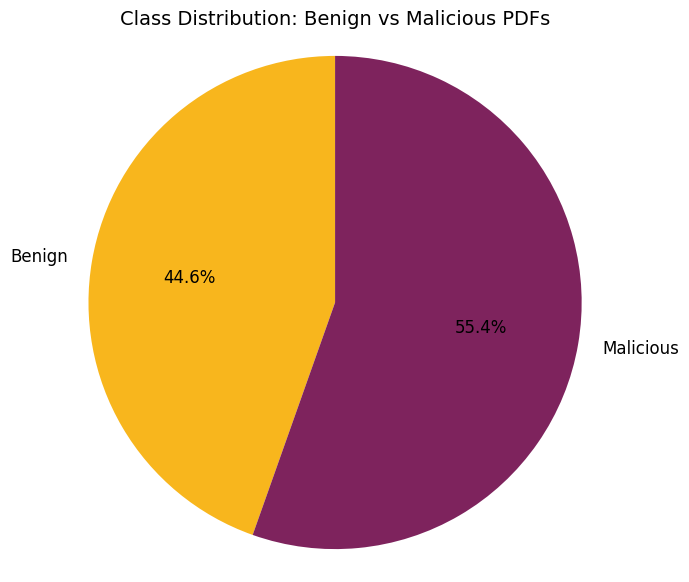

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

#1. Load your data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')

#2. Count classes (0 = Benign, 1 = Malicious)
counts = df['Class'].value_counts().sort_index()
labels = ['Benign', 'Malicious']
colors = ['#f8b61d', '#7e235d']

#3. Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 12})
plt.title('Class Distribution: Benign vs Malicious PDFs', fontsize=14)
plt.axis('equal')

#4. Save as PNG
plt.savefig('class_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

#5. Download to your PC
files.download('class_distribution_pie.png')

## **9. Feature Ranking using Random Forest**

Javascript         0.155450
JS                 0.114789
MetadataSize       0.101818
StartXref          0.089801
PdfSize            0.068567
Endobj             0.046035
XrefLength         0.044718
OpenAction         0.043097
Xref               0.042702
Stream             0.039803
Endstream          0.036133
XFA                0.026973
Obj                0.025106
Trailer            0.022969
Text               0.022240
header_version     0.017688
EmbeddedFiles      0.012685
PageNo             0.012098
Images             0.011634
TitleCharacters    0.010697
Colors             0.009687
ObjStm             0.007985
Pages              0.007768
Acroform           0.007175
EmbeddedFile       0.006491
isEncrypted        0.005800
Launch             0.003019
AA                 0.002313
RichMedia          0.001950
Encrypt            0.001672
JBIG2Decode        0.001136
dtype: float64


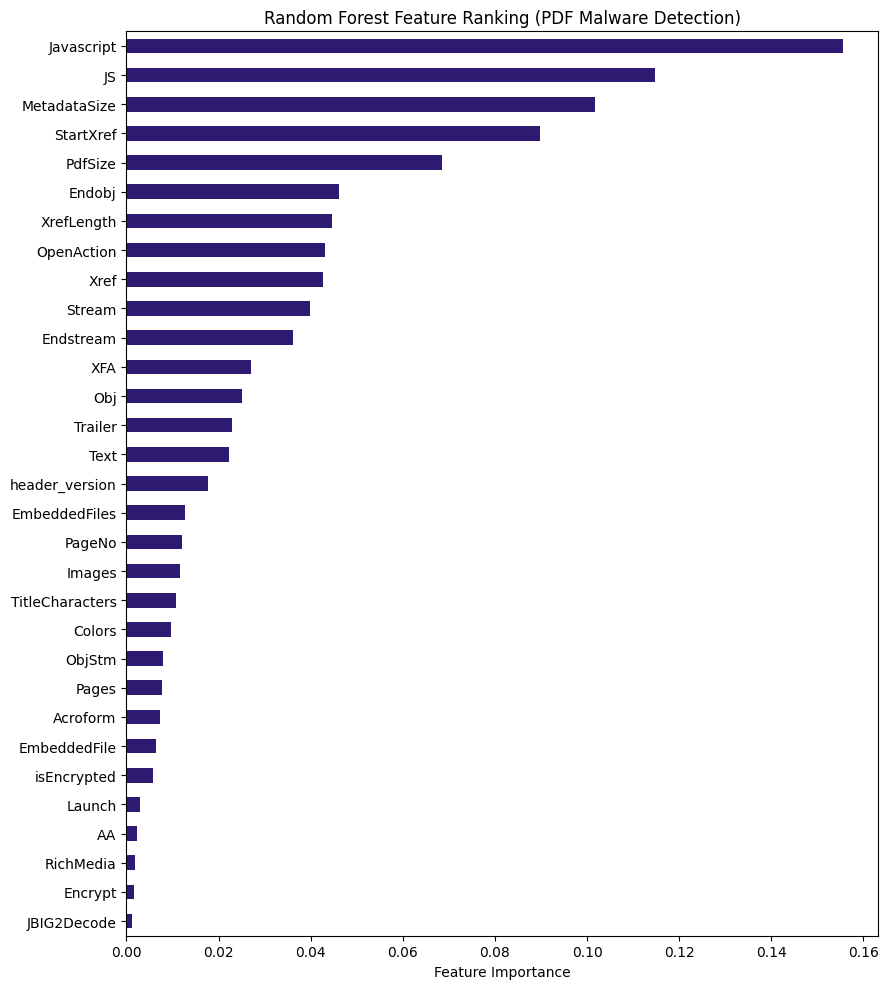

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from google.colab import files

#1. Load data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

#2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#3. Train Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

#4. Rank features by importance (no threshold, full ranking)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

#5. Plot ranking
plt.figure(figsize=(9, 10))
importances.sort_values(ascending=True).plot(kind='barh', color='#2f1a72')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Ranking (PDF Malware Detection)')
plt.tight_layout()

#6. Save + download
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('rf_feature_importance.png')

## **10. Most malicious feature ranking for signature based model**

     Feature  Individual Recall
  Javascript           0.817282
          JS           0.795680
  OpenAction           0.606661
    Acroform           0.292529
         XFA           0.180918
EmbeddedFile           0.167417
          AA           0.137714
      Launch           0.110711
   RichMedia           0.099910
 JBIG2Decode           0.091809


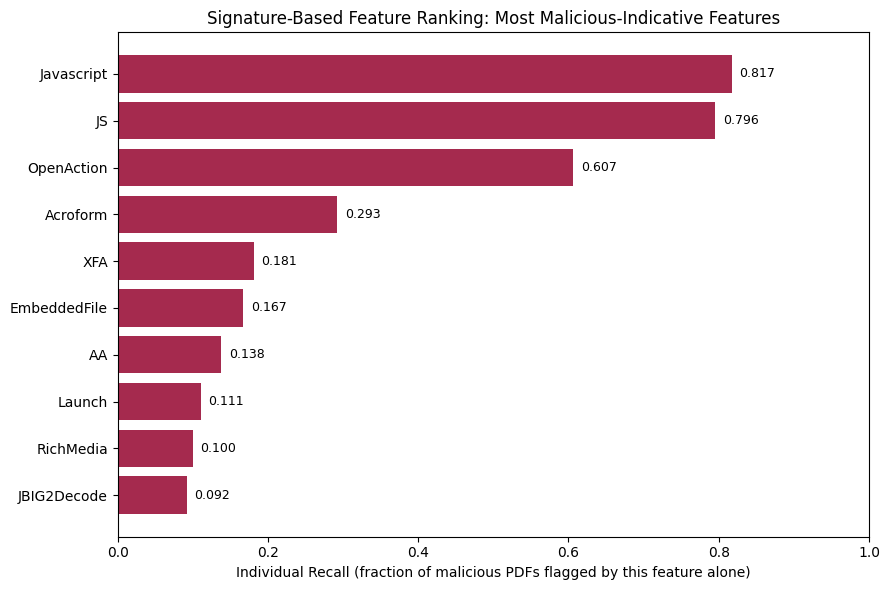

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

#1. Load data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#2. Signature-based feature set
signature_features = ['Javascript', 'JS', 'OpenAction', 'AA', 'Launch',
                       'RichMedia', 'Acroform', 'EmbeddedFile', 'XFA', 'JBIG2Decode']

#3. Rank features by "individual recall": what fraction of malicious PDFs
#does THIS single feature alone flag (feature > 0), among malicious
#PDFs in the test set
mal_mask = y_test == 1
X_test_mal = X_test.loc[mal_mask]
n_mal = len(X_test_mal)

individual_recall = {feat: (X_test_mal[feat] > 0).sum() / n_mal for feat in signature_features}

rank_df = pd.DataFrame({
    "Feature": signature_features,
    "Individual Recall": [individual_recall[f] for f in signature_features],
}).sort_values("Individual Recall", ascending=False).reset_index(drop=True)

print(rank_df.to_string(index=False))

#4. Plot ranking
plot_df = rank_df.sort_values("Individual Recall", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df['Feature'], plot_df['Individual Recall'], color='#a52a4e')
plt.xlabel('Individual Recall (fraction of malicious PDFs flagged by this feature alone)')
plt.title('Signature-Based Feature Ranking: Most Malicious-Indicative Features')
plt.xlim(0, 1.0)
for i, (feat, v) in enumerate(zip(plot_df['Feature'], plot_df['Individual Recall'])):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=9)
plt.tight_layout()

#5. Save + download
plt.savefig('signature_feature_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('signature_feature_ranking.png')

## **11. Automated List of Most Optimal Combinations of Features**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

#1. Load data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

#2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#3. Set up Random Forest as the base estimator
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#4. Sequential Forward Selection: automatically tries growing feature
#combinations (1 feature, 2 features, 3 features, ...) and scores
#each combination using cross-validated F1
sfs = SFS(rf,
          k_features=(1, 15),   # try combinations from 1 up to 15 features
          forward=True,         # forward selection (start empty, add best feature each step)
          floating=False,
          scoring='f1',
          cv=3,
          n_jobs=-1)

sfs = sfs.fit(X_train, y_train)

#5. Rank all evaluated combinations by F1 score
results = pd.DataFrame(sfs.subsets_).T
results = results[['feature_names', 'avg_score']].sort_values('avg_score', ascending=False)
results.columns = ['Feature Combination', 'F1 Score']

print(results)

#6. Best combination overall
best = results.iloc[0]
print("\nBest feature combination:")
print(best['Feature Combination'])
print("F1 score:", best['F1 Score'])

                                  Feature Combination  F1 Score
15  (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.994599
14  (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.994266
13  (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.993818
12  (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.993818
11  (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.993591
10  (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.993257
9   (PdfSize, MetadataSize, XrefLength, EmbeddedFi...  0.992918
8   (PdfSize, MetadataSize, XrefLength, Endstream,...  0.992584
7   (PdfSize, MetadataSize, XrefLength, Endstream,...  0.991458
6   (MetadataSize, XrefLength, Endstream, StartXre...  0.990226
5   (MetadataSize, XrefLength, Endstream, StartXre...  0.988291
4   (MetadataSize, XrefLength, StartXref, Javascript)  0.983009
3               (MetadataSize, XrefLength, StartXref)  0.970875
2                           (MetadataSize, StartXref)  0.943875
1                                       

## **12. All Features used in 7 models + Signature-based + Evaluation Matrix Comparison**

          Model  Accuracy  Precision   Recall  F1 Score
        XGBoost  0.994514   0.995495 0.994599  0.995047
  Random Forest  0.991022   0.989257 0.994599  0.991921
            ANN  0.989526   0.988351 0.992799  0.990570
            KNN  0.978055   0.978475 0.981998  0.980234
       AdaBoost  0.972569   0.979129 0.971197  0.975147
            SVM  0.782544   0.726967 0.972997  0.832179
Signature-Based  0.740150   0.702055 0.922592  0.797355
    Naive Bayes  0.575062   0.970909 0.240324  0.385281


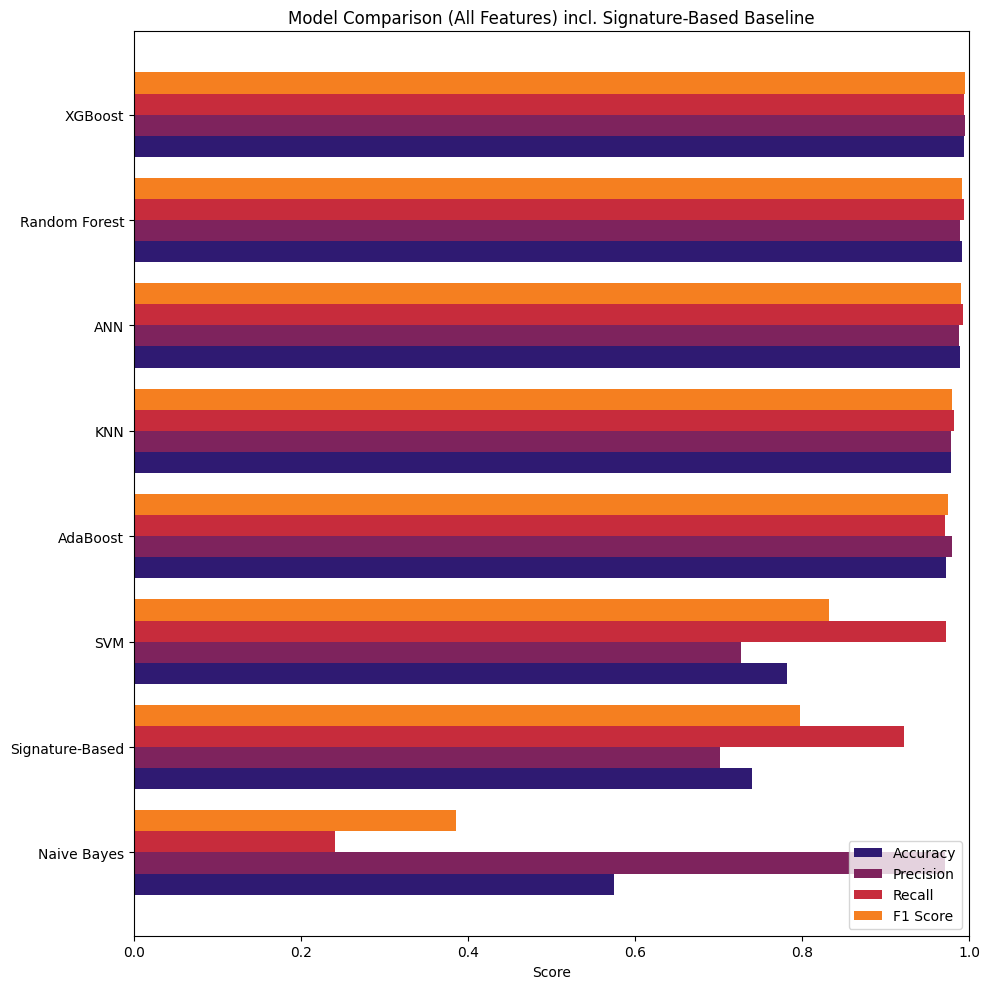

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#1. Load data (ALL features)
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

#2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#3. Define all 7 ML models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

#4. Train + evaluate each ML model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

#5. Signature/rule-based baseline (traditional detection)
signature_features = ['Javascript', 'JS', 'OpenAction', 'AA', 'Launch',
                       'RichMedia', 'Acroform', 'EmbeddedFile', 'XFA', 'JBIG2Decode']

def signature_based_predict(data):
    return (data[signature_features] > 0).any(axis=1).astype(int)

y_pred_sig = signature_based_predict(X_test)
results.append({
    "Model": "Signature-Based",
    "Accuracy": accuracy_score(y_test, y_pred_sig),
    "Precision": precision_score(y_test, y_pred_sig),
    "Recall": recall_score(y_test, y_pred_sig),
    "F1 Score": f1_score(y_test, y_pred_sig)
})

#6. Combine + rank by F1
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

#7. Plot horizontal bar chart
results_df_plot = results_df.iloc[::-1].reset_index(drop=True)  # best model on top
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
yv = np.arange(len(results_df_plot))
height = 0.2
colors = ['#2f1a72', '#7e235d', '#c72c3c', '#f57f20']

plt.figure(figsize=(10, 10))
for i, metric in enumerate(metrics):
    plt.barh(yv + i*height, results_df_plot[metric], height, label=metric, color=colors[i])

plt.yticks(yv + height*1.5, results_df_plot['Model'])
plt.xlabel('Score')
plt.xlim(0.0, 1.0)
plt.title('Model Comparison (All Features) incl. Signature-Based Baseline')
plt.legend(loc='lower right')
plt.tight_layout()

#8. Save + download
plt.savefig('model_comparison_with_signature_hbar.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('model_comparison_with_signature_hbar.png')

## **13. Top Ranked Combination Features used in 7 models + Signature-based + Evaluation Matrix**

          Model  Accuracy  Precision   Recall  F1 Score
        XGBoost  0.991521   0.989267 0.995500  0.992373
  Random Forest  0.991022   0.989257 0.994599  0.991921
            ANN  0.980050   0.983740 0.980198  0.981966
            KNN  0.970574   0.971326 0.975698  0.973507
       AdaBoost  0.960100   0.963163 0.964896  0.964029
Signature-Based  0.740150   0.702055 0.922592  0.797355
            SVM  0.676808   0.633738 0.987399  0.771992
    Naive Bayes  0.478803   0.892857 0.067507  0.125523


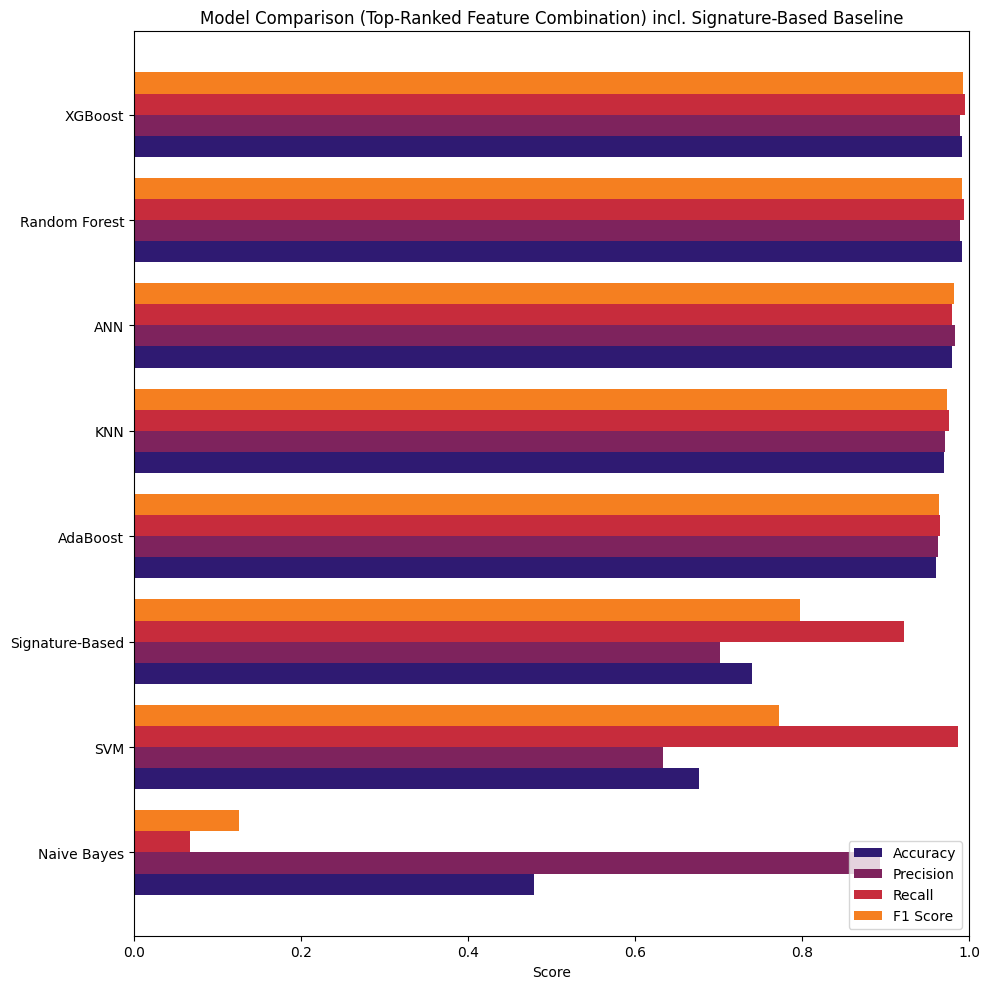

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#1. Load data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')

# 2. Top-ranked optimal feature combination
best_features = ['PdfSize', 'MetadataSize', 'XrefLength', 'Endobj', 'Stream',
                  'StartXref', 'Javascript', 'RichMedia', 'Colors', 'header_version']

X_full = df.drop(columns=['Class'])   # keep full feature set for the signature baseline
y = df['Class']

#3. Single train/test split (same random_state/stratify as the "All Features" cell,
# so ML models and the signature baseline are evaluated on identical rows)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train_full[best_features]
X_test = X_test_full[best_features]

# 4. Define all 7 ML models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# 5. Train + evaluate each ML model on the top-ranked features
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

#  6. Signature/rule-based baseline (uses the full original signature feature set,
#  not the top-ranked subset — it's a separate rule-based detector, not an ML model)
signature_features = ['Javascript', 'JS', 'OpenAction', 'AA', 'Launch',
                       'RichMedia', 'Acroform', 'EmbeddedFile', 'XFA', 'JBIG2Decode']

def signature_based_predict(data):
    return (data[signature_features] > 0).any(axis=1).astype(int)

y_pred_sig = signature_based_predict(X_test_full)
results.append({
    "Model": "Signature-Based",
    "Accuracy": accuracy_score(y_test, y_pred_sig),
    "Precision": precision_score(y_test, y_pred_sig),
    "Recall": recall_score(y_test, y_pred_sig),
    "F1 Score": f1_score(y_test, y_pred_sig)
})

# ---- 7. Combine + rank by F1 ----
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# ---- 8. Plot horizontal bar chart ----
results_df_plot = results_df.iloc[::-1].reset_index(drop=True)  # best model on top
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
yv = np.arange(len(results_df_plot))
height = 0.2
colors = ['#2f1a72', '#7e235d', '#c72c3c', '#f57f20']

plt.figure(figsize=(10, 10))
for i, metric in enumerate(metrics):
    plt.barh(yv + i*height, results_df_plot[metric], height, label=metric, color=colors[i])

plt.yticks(yv + height*1.5, results_df_plot['Model'])
plt.xlabel('Score')
plt.xlim(0.0, 1.0)
plt.title('Model Comparison (Top-Ranked Feature Combination) incl. Signature-Based Baseline')
plt.legend(loc='lower right')
plt.tight_layout()

# ---- 9. Save + download ----
plt.savefig('model_comparison_topranked_with_signature_hbar.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('model_comparison_topranked_with_signature_hbar.png')

## **14. 2nd most Optimal Combination Features used in 7 models + Signature-based + Evaluation Matrix**

          Model  Accuracy  Precision   Recall  F1 Score
        XGBoost  0.991022   0.988382 0.995500  0.991928
  Random Forest  0.989526   0.987478 0.993699  0.990579
            KNN  0.973067   0.974843 0.976598  0.975719
            ANN  0.972070   0.970562 0.979298  0.974910
       AdaBoost  0.965586   0.977982 0.959496  0.968651
Signature-Based  0.740150   0.702055 0.922592  0.797355
            SVM  0.671820   0.629948 0.988299  0.769446
    Naive Bayes  0.479800   0.895349 0.069307  0.128655


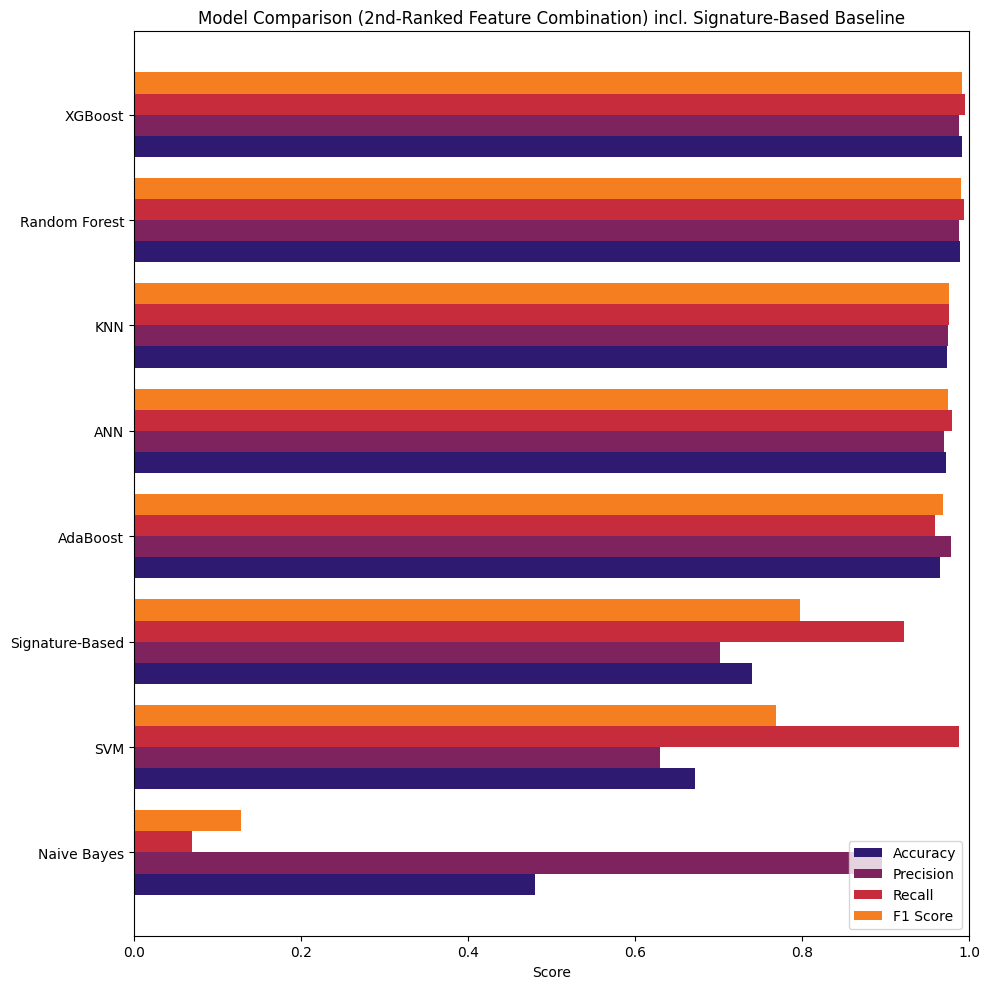

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')

# 2. 2nd-ranked optimal feature combination
second_best_features = ['MetadataSize', 'XrefLength', 'Endobj', 'Stream',
                         'StartXref', 'Javascript', 'RichMedia', 'Colors', 'header_version']

X_full = df.drop(columns=['Class'])   # keep full feature set for the signature baseline
y = df['Class']

# 3. Single train/test split (same random_state/stratify as other cells,
#         so ML models and the signature baseline are evaluated on identical rows)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train_full[second_best_features]
X_test = X_test_full[second_best_features]

# 4. Define all 7 ML models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# 5. Train + evaluate each ML model on the 2nd-ranked features
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# 6. Signature/rule-based baseline (uses the full original signature feature set,
#         not the top-ranked subset — it's a separate rule-based detector, not an ML model)
signature_features = ['Javascript', 'JS', 'OpenAction', 'AA', 'Launch',
                       'RichMedia', 'Acroform', 'EmbeddedFile', 'XFA', 'JBIG2Decode']

def signature_based_predict(data):
    return (data[signature_features] > 0).any(axis=1).astype(int)

y_pred_sig = signature_based_predict(X_test_full)
results.append({
    "Model": "Signature-Based",
    "Accuracy": accuracy_score(y_test, y_pred_sig),
    "Precision": precision_score(y_test, y_pred_sig),
    "Recall": recall_score(y_test, y_pred_sig),
    "F1 Score": f1_score(y_test, y_pred_sig)
})

# 7. Combine + rank by F1
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# 8. Plot horizontal bar chart
results_df_plot = results_df.iloc[::-1].reset_index(drop=True)  # best model on top
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
yv = np.arange(len(results_df_plot))
height = 0.2
colors = ['#2f1a72', '#7e235d', '#c72c3c', '#f57f20']

plt.figure(figsize=(10, 10))
for i, metric in enumerate(metrics):
    plt.barh(yv + i*height, results_df_plot[metric], height, label=metric, color=colors[i])

plt.yticks(yv + height*1.5, results_df_plot['Model'])
plt.xlabel('Score')
plt.xlim(0.0, 1.0)
plt.title('Model Comparison (2nd-Ranked Feature Combination) incl. Signature-Based Baseline')
plt.legend(loc='lower right')
plt.tight_layout()

# 9. Save + download
plt.savefig('model_comparison_2ndranked_with_signature_hbar.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('model_comparison_2ndranked_with_signature_hbar.png')

## **15. All Model Comparison**

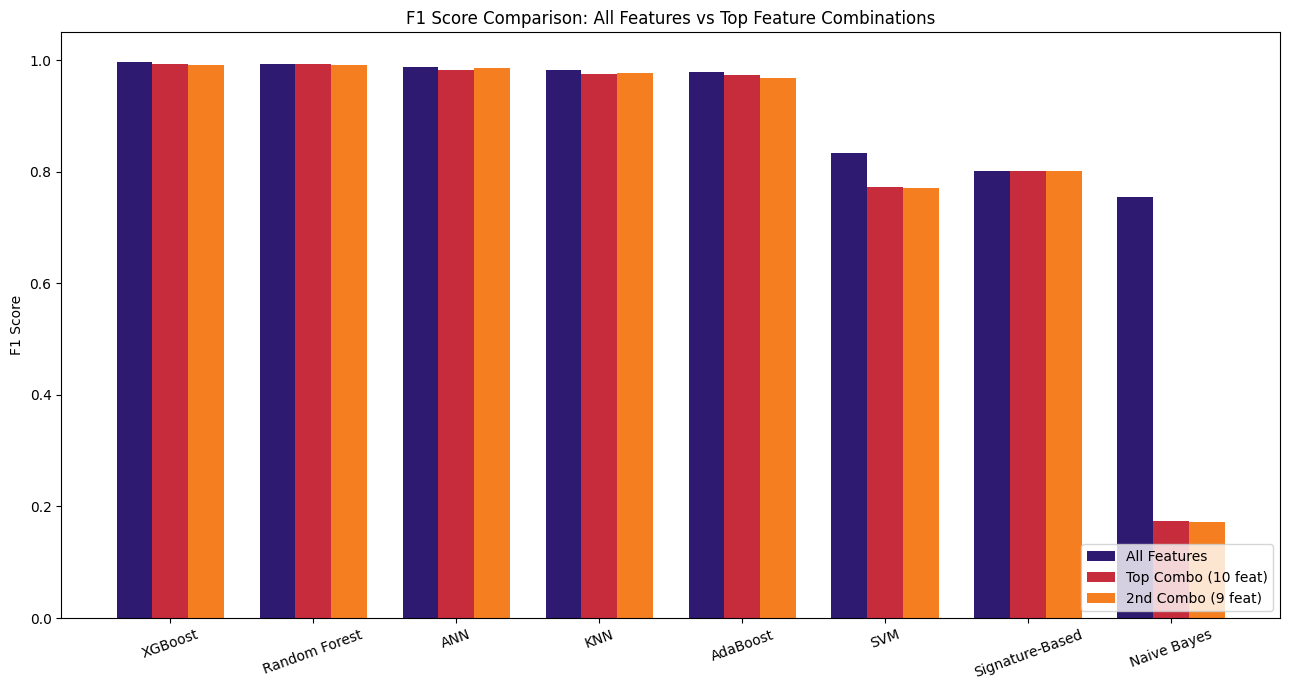

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

data = {
    "Model": ["Random Forest", "SVM", "Naive Bayes", "AdaBoost", "KNN", "ANN", "XGBoost", "Signature-Based"],
    "All Features": [0.9933, 0.8342, 0.7557, 0.9789, 0.9820, 0.9874, 0.9960, 0.8020],
    "Top Combo (10 feat)": [0.9924, 0.7724, 0.1747, 0.9730, 0.9758, 0.9820, 0.9924, 0.8020],
    "2nd Combo (9 feat)": [0.9915, 0.7706, 0.1717, 0.9678, 0.9776, 0.9861, 0.9919, 0.8020],
}
df = pd.DataFrame(data)
df = df.sort_values("All Features", ascending=False).reset_index(drop=True)

x = np.arange(len(df))
width = 0.25
colors = ['#2f1a72', '#c72c3c', '#f57f20']

plt.figure(figsize=(13, 7))
plt.bar(x - width, df["All Features"], width, label="All Features", color=colors[0])
plt.bar(x, df["Top Combo (10 feat)"], width, label="Top Combo (10 feat)", color=colors[1])
plt.bar(x + width, df["2nd Combo (9 feat)"], width, label="2nd Combo (9 feat)", color=colors[2])

plt.xticks(x, df['Model'], rotation=20)
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.title('F1 Score Comparison: All Features vs Top Feature Combinations')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('f1_comparison_feature_sets.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('f1_comparison_feature_sets.png')

## **16. Evasive/Malicious Clustering to check Recall drop**


          Model  Recall (Typical Malicious)  Recall (Evasive Malicious)  Recall Drop
  Random Forest                       1.000                    0.994398     0.005602
        XGBoost                       1.000                    0.994398     0.005602
            ANN                       1.000                    0.992530     0.007470
            KNN                       1.000                    0.981326     0.018674
            SVM                       1.000                    0.971989     0.028011
       AdaBoost                       1.000                    0.970121     0.029879
Signature-Based                       0.975                    0.920635     0.054365
    Naive Bayes                       1.000                    0.211951     0.788049


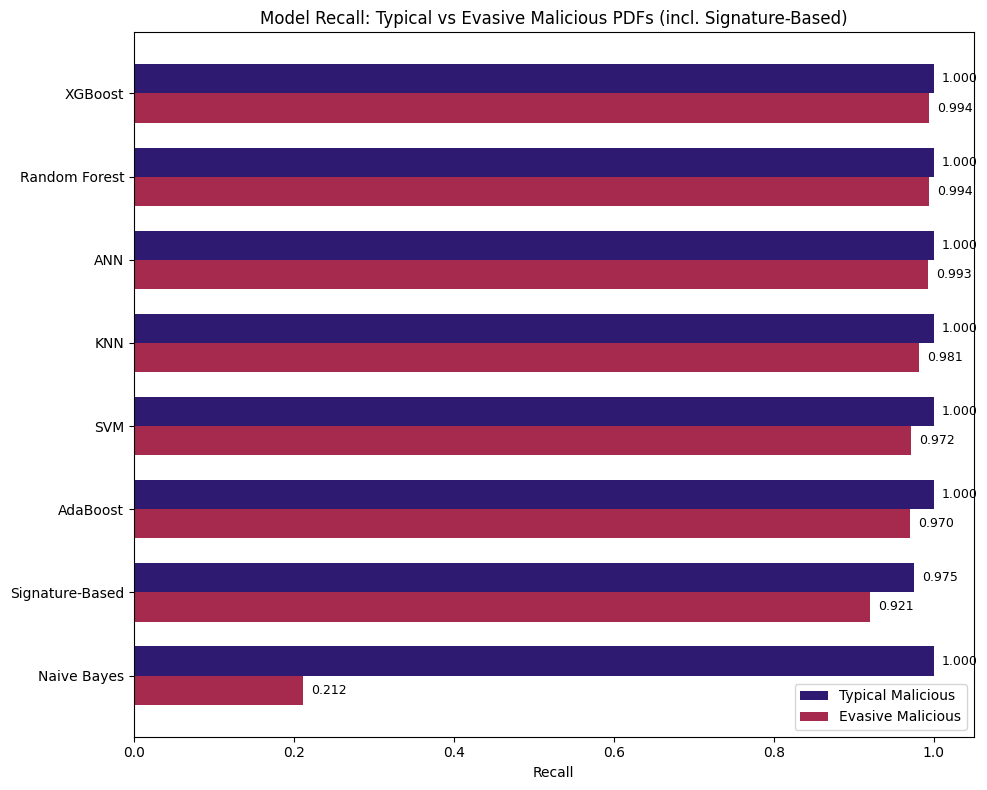

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

#1. Load data
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

#2. Identify evasive vs typical malicious via K-means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
cluster_majority = pd.Series(y).groupby(cluster_labels).mean()
benign_dominant_cluster = cluster_majority.idxmin()

is_evasive = (y == 1) & (pd.Series(cluster_labels, index=X.index) == benign_dominant_cluster)
is_typical_malicious = (y == 1) & (pd.Series(cluster_labels, index=X.index) != benign_dominant_cluster)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

evasive_test_idx = X_test.index[is_evasive.loc[X_test.index]]
typical_test_idx = X_test.index[is_typical_malicious.loc[X_test.index]]

X_test_evasive, y_test_evasive = X_test.loc[evasive_test_idx], y_test.loc[evasive_test_idx]
X_test_typical, y_test_typical = X_test.loc[typical_test_idx], y_test.loc[typical_test_idx]

#3. Train + evaluate all 7 ML models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    rec_typical = recall_score(y_test_typical, model.predict(X_test_typical))
    rec_evasive = recall_score(y_test_evasive, model.predict(X_test_evasive))
    results.append({"Model": name, "Recall (Typical Malicious)": rec_typical, "Recall (Evasive Malicious)": rec_evasive})

#4. Signature-based baseline
signature_features = ['Javascript', 'JS', 'OpenAction', 'AA', 'Launch',
                       'RichMedia', 'Acroform', 'EmbeddedFile', 'XFA', 'JBIG2Decode']

def signature_based_predict(data):
    return (data[signature_features] > 0).any(axis=1).astype(int)

rec_typical_sig = recall_score(y_test_typical, signature_based_predict(X_test_typical))
rec_evasive_sig = recall_score(y_test_evasive, signature_based_predict(X_test_evasive))
results.append({"Model": "Signature-Based", "Recall (Typical Malicious)": rec_typical_sig, "Recall (Evasive Malicious)": rec_evasive_sig})

#5. Combine, compute recall drop
results_df = pd.DataFrame(results)
results_df["Recall Drop"] = results_df["Recall (Typical Malicious)"] - results_df["Recall (Evasive Malicious)"]
print(results_df.sort_values("Recall Drop").to_string(index=False))

#6. Plot
plot_df = results_df.sort_values("Recall (Evasive Malicious)", ascending=True).reset_index(drop=True)
yv = np.arange(len(plot_df))
height = 0.35

plt.figure(figsize=(10, 8))
plt.barh(yv + height/2, plot_df["Recall (Typical Malicious)"], height, label="Typical Malicious", color='#2f1a72')
plt.barh(yv - height/2, plot_df["Recall (Evasive Malicious)"], height, label="Evasive Malicious", color='#a52a4e')

plt.yticks(yv, plot_df['Model'])
plt.xlabel('Recall')
plt.xlim(0, 1.05)
plt.title('Model Recall: Typical vs Evasive Malicious PDFs (incl. Signature-Based)')
plt.legend(loc='lower right')

for i, row in plot_df.iterrows():
    plt.text(row["Recall (Typical Malicious)"] + 0.01, i + height/2, f"{row['Recall (Typical Malicious)']:.3f}", va='center', fontsize=9)
    plt.text(row["Recall (Evasive Malicious)"] + 0.01, i - height/2, f"{row['Recall (Evasive Malicious)']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('evasion_resistance_with_signature.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('evasion_resistance_with_signature.png')

## **17. SHAP and LIME install**

In [ ]:
!pip install shap lime

## **18. XAI for the XGBoost**

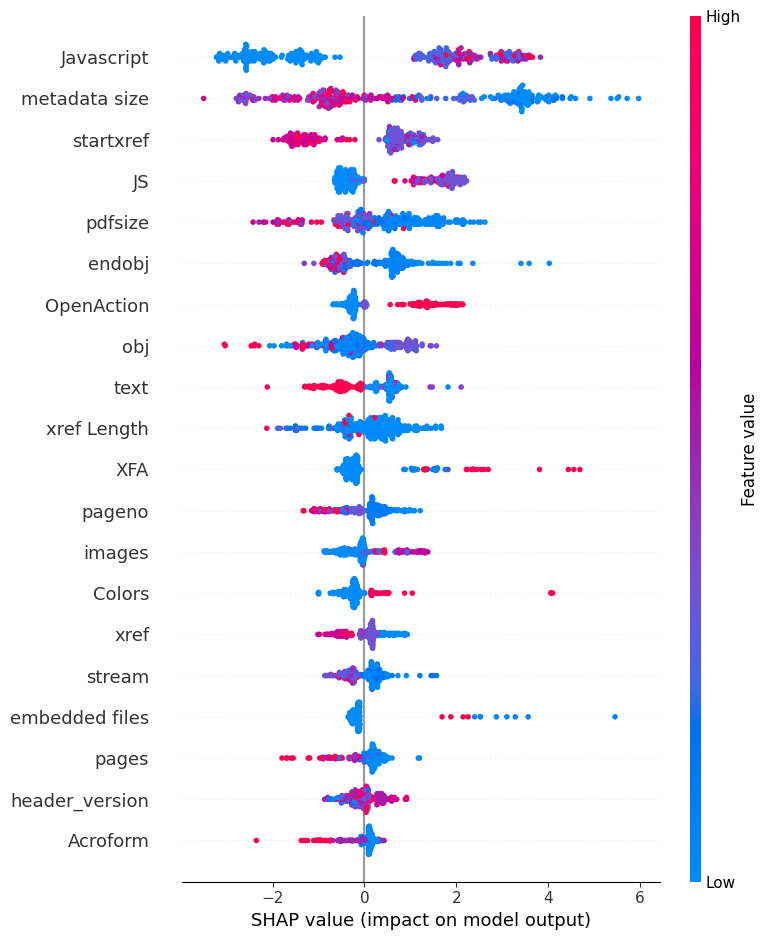

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

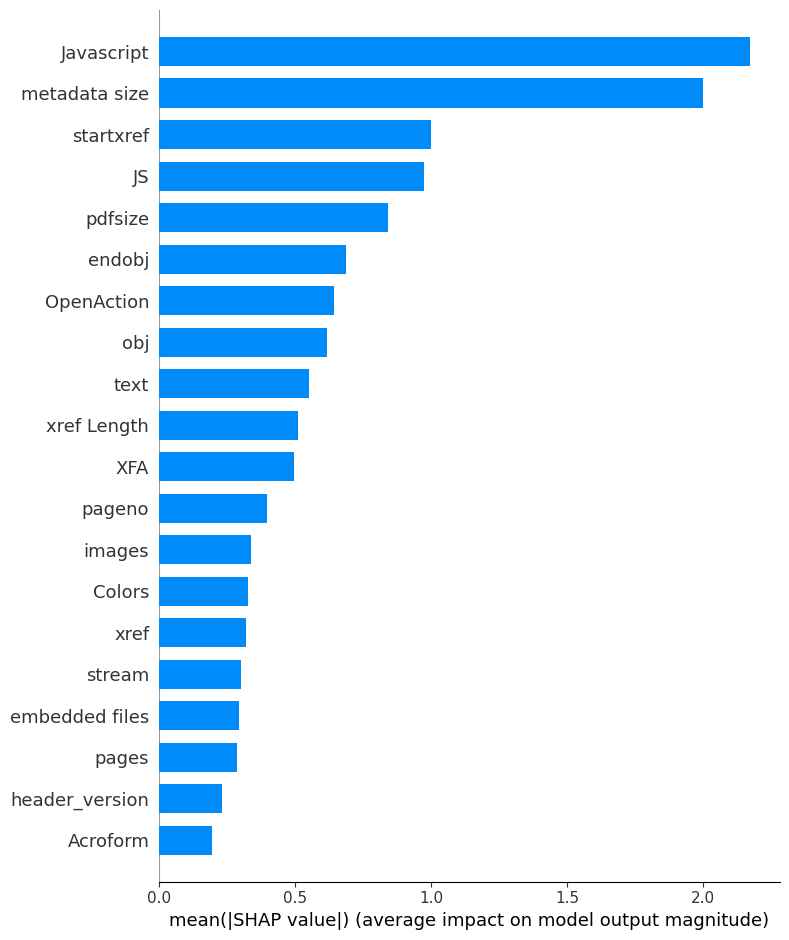

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

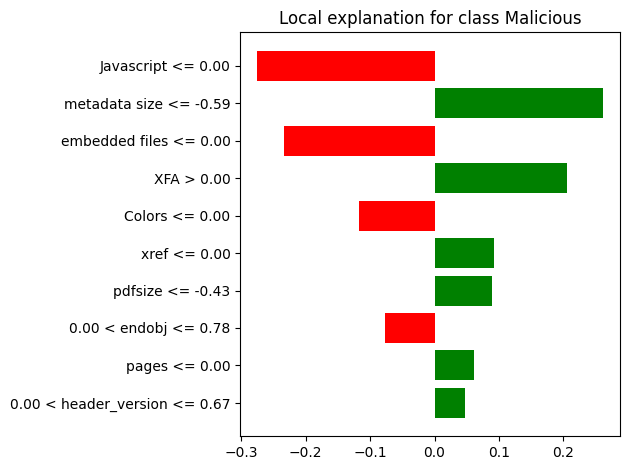

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

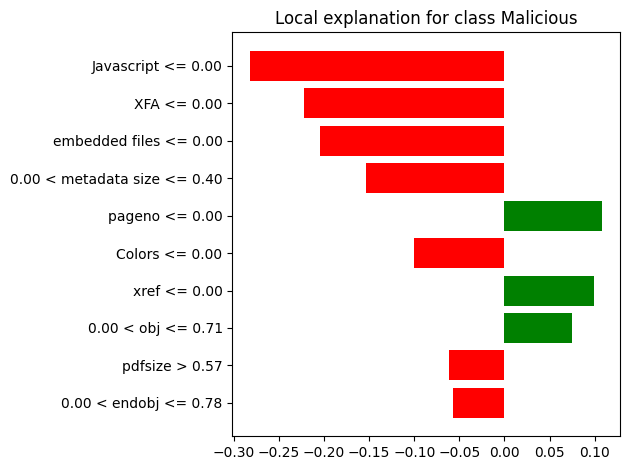

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import shap
import lime
import lime.lime_tabular

# 1. Load data (all features — best-performing setup)
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#2. Train the best model (XGBoost) for interpretation
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

explainer_shap = shap.TreeExplainer(xgb)
sample = X_test.sample(300, random_state=42)   # subsample for speed; increase if you want
shap_values = explainer_shap.shap_values(sample)

#SHAP summary (beeswarm) plot
plt.figure()
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig('shap_summary_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('shap_summary_xgboost.png')

# SHAP mean |value| bar plot
plt.figure()
shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('shap_bar_xgboost.png')

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Malicious'],
    mode='classification'
)

# Explain one correctly-flagged malicious PDF
mal_idx = y_test[y_test == 1].index[0]
instance_mal = X_test.loc[mal_idx].values

exp_mal = explainer_lime.explain_instance(instance_mal, xgb.predict_proba, num_features=10)
fig_mal = exp_mal.as_pyplot_figure()
fig_mal.tight_layout()
fig_mal.savefig('lime_explanation_malicious.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('lime_explanation_malicious.png')

# Explain one correctly-flagged benign PDF
ben_idx = y_test[y_test == 0].index[0]
instance_ben = X_test.loc[ben_idx].values

exp_ben = explainer_lime.explain_instance(instance_ben, xgb.predict_proba, num_features=10)
fig_ben = exp_ben.as_pyplot_figure()
fig_ben.tight_layout()
fig_ben.savefig('lime_explanation_benign.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('lime_explanation_benign.png')

## **19. XAI for the Random Forest**

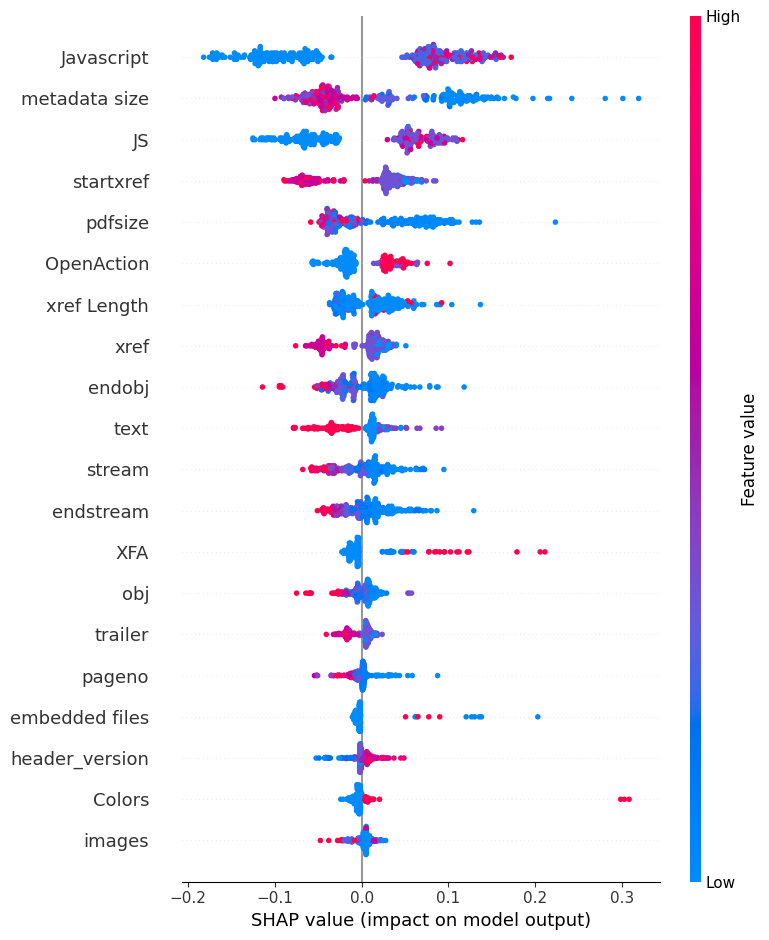

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

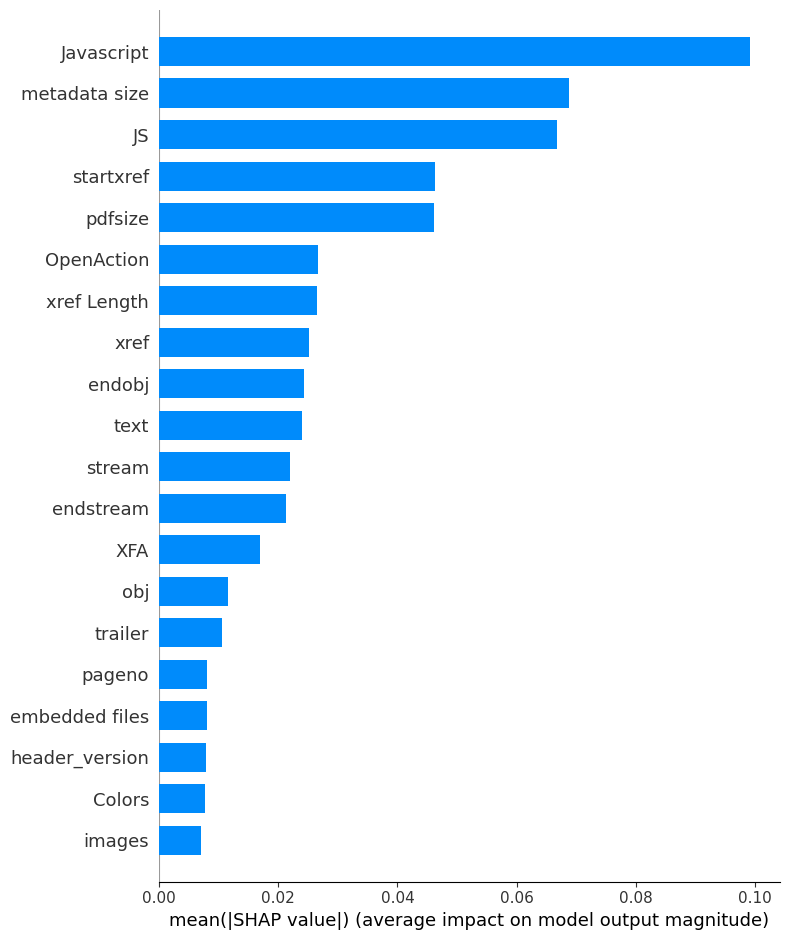

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

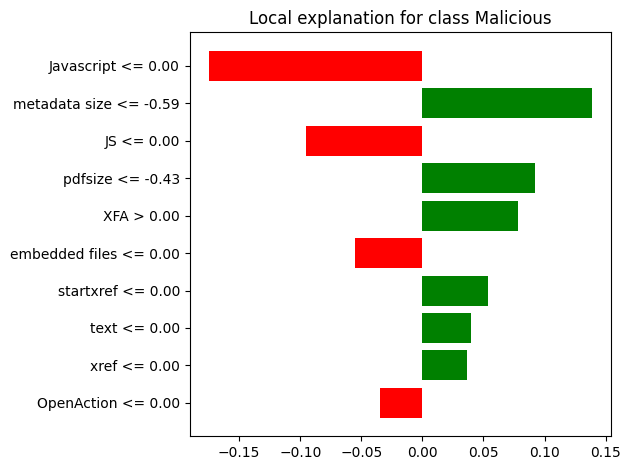

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

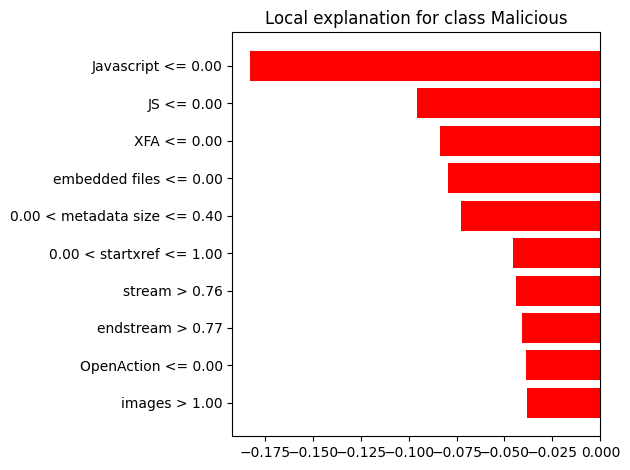

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap
import lime
import lime.lime_tabular

# 1. Load data (all features)
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

explainer_shap = shap.TreeExplainer(rf)
sample = X_test.sample(300, random_state=42)
shap_values = explainer_shap.shap_values(sample)

# Random Forest's TreeExplainer returns shap values for both classes
# (shape: [n_samples, n_features, 2]) — we take the "Malicious" class (index 1)
if isinstance(shap_values, list):
    shap_values_mal = shap_values[1]
else:
    shap_values_mal = shap_values[:, :, 1]

#SHAP summary (beeswarm) plot
plt.figure()
shap.summary_plot(shap_values_mal, sample, show=False)
plt.tight_layout()
plt.savefig('shap_summary_rf.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('shap_summary_rf.png')

# SHAP mean |value| bar plot
plt.figure()
shap.summary_plot(shap_values_mal, sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_rf.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('shap_bar_rf.png')

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Malicious'],
    mode='classification'
)

# Explain one malicious PDF
mal_idx = y_test[y_test == 1].index[0]
instance_mal = X_test.loc[mal_idx].values

exp_mal = explainer_lime.explain_instance(instance_mal, rf.predict_proba, num_features=10)
fig_mal = exp_mal.as_pyplot_figure()
fig_mal.tight_layout()
fig_mal.savefig('lime_explanation_malicious_rf.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('lime_explanation_malicious_rf.png')

# Explain one benign PDF
ben_idx = y_test[y_test == 0].index[0]
instance_ben = X_test.loc[ben_idx].values

exp_ben = explainer_lime.explain_instance(instance_ben, rf.predict_proba, num_features=10)
fig_ben = exp_ben.as_pyplot_figure()
fig_ben.tight_layout()
fig_ben.savefig('lime_explanation_benign_rf.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('lime_explanation_benign_rf.png')

## **20. 5 fold cross validation code**


          Model  Accuracy Mean  Accuracy Std  F1 Mean   F1 Std
        XGBoost       0.995112      0.001196 0.995590 0.001078
  Random Forest       0.993415      0.000797 0.994067 0.000717
            ANN       0.988028      0.001865 0.989198 0.001688
            KNN       0.977152      0.001320 0.979385 0.001207
       AdaBoost       0.976255      0.004072 0.978491 0.003735
            SVM       0.779607      0.007149 0.830211 0.004855
Signature-Based       0.741394      0.009018 0.799518 0.006477
    Naive Bayes       0.720030      0.085686 0.651457 0.158113


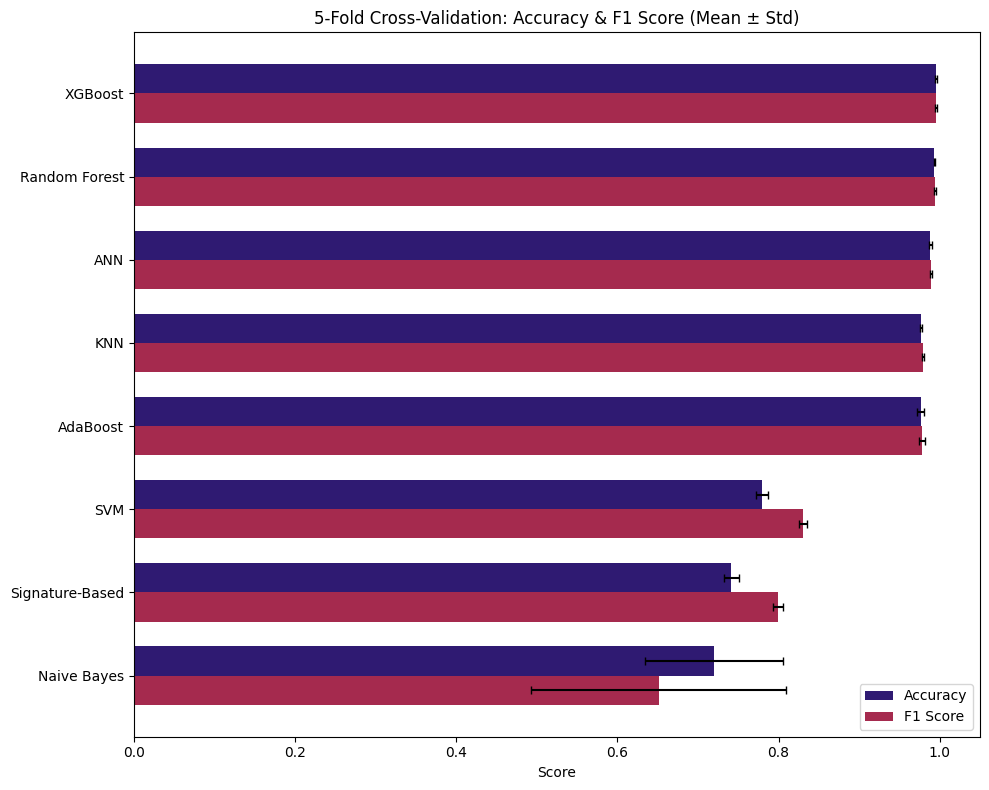

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Load data (ALL features)
df = pd.read_csv('CIC-Evasive-PDFMal2022_cleaned_mean_scaled.csv')
X = df.drop(columns=['Class'])
y = df['Class']

# 2. Define all 7 ML models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# 3. Signature-based rule
signature_features = ['Javascript', 'JS', 'OpenAction', 'AA', 'Launch',
                       'RichMedia', 'Acroform', 'EmbeddedFile', 'XFA', 'JBIG2Decode']

def signature_based_predict(data):
    return (data[signature_features] > 0).any(axis=1).astype(int)

#4. 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    accs, f1s = [], []
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        m = clone(model)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        accs.append(accuracy_score(y_te, pred))
        f1s.append(f1_score(y_te, pred))
    results.append({
        "Model": name,
        "Accuracy Mean": np.mean(accs), "Accuracy Std": np.std(accs),
        "F1 Mean": np.mean(f1s), "F1 Std": np.std(f1s)
    })

# Signature-based baseline evaluated on the SAME folds (no training needed)
accs, f1s = [], []
for train_idx, test_idx in skf.split(X, y):
    X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]
    pred = signature_based_predict(X_te)
    accs.append(accuracy_score(y_te, pred))
    f1s.append(f1_score(y_te, pred))
results.append({
    "Model": "Signature-Based",
    "Accuracy Mean": np.mean(accs), "Accuracy Std": np.std(accs),
    "F1 Mean": np.mean(f1s), "F1 Std": np.std(f1s)
})

# 5. Combine + rank
results_df = pd.DataFrame(results).sort_values("F1 Mean", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

#6. Plot
results_df_plot = results_df.iloc[::-1].reset_index(drop=True)
yv = np.arange(len(results_df_plot))
height = 0.35

plt.figure(figsize=(10, 8))
plt.barh(yv + height/2, results_df_plot["Accuracy Mean"], height, xerr=results_df_plot["Accuracy Std"],
          label="Accuracy", color='#2f1a72', capsize=3)
plt.barh(yv - height/2, results_df_plot["F1 Mean"], height, xerr=results_df_plot["F1 Std"],
          label="F1 Score", color='#a52a4e', capsize=3)

plt.yticks(yv, results_df_plot['Model'])
plt.xlabel('Score')
plt.xlim(0, 1.05)
plt.title('5-Fold Cross-Validation: Accuracy & F1 Score (Mean ± Std)')
plt.legend(loc='lower right')
plt.tight_layout()

#  7. Save + download
plt.savefig('cv_5fold_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('cv_5fold_comparison.png')

## **21. Computational performance**

In [ ]:
import time

N_REPEATS = 5
timing_results = []

for name, model in models.items():
    m = clone(model)
    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    pred_times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        m.predict(X_test)
        pred_times.append(time.perf_counter() - t0)
    avg_pred_time = np.mean(pred_times)

    timing_results.append({
        "Model": name,
        "Train Time (s)": train_time,
        "Inference Time - Full Test Set (s)": avg_pred_time,
        "Inference per PDF (ms)": (avg_pred_time / len(X_test)) * 1000,
        "Throughput (PDFs/sec)": len(X_test) / avg_pred_time
    })

# Signature-based baseline (vectorized pandas check)
sig_times = []
for _ in range(N_REPEATS):
    t0 = time.perf_counter()
    signature_based_predict(X_test)
    sig_times.append(time.perf_counter() - t0)
avg_sig_time = np.mean(sig_times)
timing_results.append({
    "Model": "Signature-Based",
    "Train Time (s)": 0.0,
    "Inference Time - Full Test Set (s)": avg_sig_time,
    "Inference per PDF (ms)": (avg_sig_time / len(X_test)) * 1000,
    "Throughput (PDFs/sec)": len(X_test) / avg_sig_time
})

timing_df = pd.DataFrame(timing_results).sort_values("Train Time (s)")
print(timing_df.to_string(index=False))

          Model  Train Time (s)  Inference Time - Full Test Set (s)  Inference per PDF (ms)  Throughput (PDFs/sec)
Signature-Based        0.000000                            0.001618                0.000807           1.239414e+06
            KNN        0.002951                            0.109388                0.054558           1.832918e+04
    Naive Bayes        0.005962                            0.001871                0.000933           1.071840e+06
        XGBoost        0.264269                            0.007401                0.003691           2.709096e+05
       AdaBoost        0.475719                            0.019483                0.009717           1.029108e+05
  Random Forest        2.023286                            0.101296                0.050522           1.979342e+04
            ANN        3.931984                            0.003450                0.001721           5.812246e+05
            SVM        4.213972                            1.149073             